In [3]:
# import required libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

In [4]:
# load dataset

df = pd.read_csv("Bitcoin Historical Data (1).csv")
df

,Date,Price,Open,High,Low,Vol.,Change %
0,24-03-2024,"67,211.9","64,036.5","67,587.8","63,812.9",65.59K,4.96%
1,23-03-2024,"64,037.8","63,785.6","65,972.4","63,074.9",35.11K,0.40%
2,22-03-2024,"63,785.5","65,501.5","66,633.3","62,328.3",72.43K,-2.62%
3,21-03-2024,"65,503.8","67,860.0","68,161.7","64,616.1",75.26K,-3.46%
4,20-03-2024,"67,854.0","62,046.8","68,029.5","60,850.9",133.53K,9.35%
...,...,...,...,...,...,...,...
4994,22-07-2010,0.1,0.1,0.1,0.1,2.16K,0.00%
4995,21-07-2010,0.1,0.1,0.1,0.1,0.58K,0.00%
4996,20-07-2010,0.1,0.1,0.1,0.1,0.26K,0.00%
4997,19-07-2010,0.1,0.1,0.1,0.1,0.57K,0.00%


In [5]:
# change date format

df['Date'] = pd.to_datetime(df['Date'], format="%d-%m-%Y")
df = df.sort_values(by="Date", ascending=True)
df

,Date,Price,Open,High,Low,Vol.,Change %
4998,2010-07-18,0.1,0.0,0.1,0.1,0.08K,0.00%
4997,2010-07-19,0.1,0.1,0.1,0.1,0.57K,0.00%
4996,2010-07-20,0.1,0.1,0.1,0.1,0.26K,0.00%
4995,2010-07-21,0.1,0.1,0.1,0.1,0.58K,0.00%
4994,2010-07-22,0.1,0.1,0.1,0.1,2.16K,0.00%
...,...,...,...,...,...,...,...
4,2024-03-20,"67,854.0","62,046.8","68,029.5","60,850.9",133.53K,9.35%
3,2024-03-21,"65,503.8","67,860.0","68,161.7","64,616.1",75.26K,-3.46%
2,2024-03-22,"63,785.5","65,501.5","66,633.3","62,328.3",72.43K,-2.62%
1,2024-03-23,"64,037.8","63,785.6","65,972.4","63,074.9",35.11K,0.40%


In [6]:
# check info

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4999 entries, 4998 to 0
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      4999 non-null   datetime64[us]
 1   Price     4999 non-null   str           
 2   Open      4999 non-null   str           
 3   High      4999 non-null   str           
 4   Low       4999 non-null   str           
 5   Vol.      4993 non-null   str           
 6   Change %  4999 non-null   str           
dtypes: datetime64[us](1), str(6)
memory usage: 451.5 KB


In [7]:
# change str to float

def clean_numeric_columns(df, cols):
    for col in cols:
        # Force to string for cleaning
        df[col] = df[col].astype(str)

        # Remove commas and % signs
        df[col] = df[col].str.replace(',', '').str.replace('%', '')

        # Replace suffixes with scientific notation
        df[col] = df[col].str.replace('K', 'e3')
        df[col] = df[col].str.replace('M', 'e6')
        df[col] = df[col].str.replace('B', 'e9')

        # Final conversion to float
        df[col] = df[col].astype(float)
    return df


In [8]:
# cleaning

numeric_cols = ['Price','Open','High','Low','Vol.','Change %']
df = clean_numeric_columns(df, numeric_cols)


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4999 entries, 4998 to 0
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      4999 non-null   datetime64[us]
 1   Price     4999 non-null   float64       
 2   Open      4999 non-null   float64       
 3   High      4999 non-null   float64       
 4   Low       4999 non-null   float64       
 5   Vol.      4993 non-null   float64       
 6   Change %  4999 non-null   float64       
dtypes: datetime64[us](1), float64(6)
memory usage: 273.5 KB


In [10]:
# preprocessing

from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np

# Numeric columns to scale
numeric_cols = ['Price','Open','High','Low','Vol.','Change %']

# Step 1: Clean NaNs
# Drop rows with missing values OR interpolate them
df[numeric_cols] = df[numeric_cols].replace('-', np.nan)   # if your CSV has '-' for missing
df[numeric_cols] = df[numeric_cols].astype(float)

# Option A: Drop missing rows
df = df.dropna(subset=numeric_cols)

# Option B: Interpolate missing values (better for time series)
# df[numeric_cols] = df[numeric_cols].interpolate(method='linear')

# Step 2: Scale numeric data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[numeric_cols])

# Step 3: Rebuild DataFrame with scaled values
scaled_df = pd.DataFrame(scaled_data, columns=numeric_cols, index=df.index)

# Step 4: Keep Date as column or index
scaled_df['Date'] = df['Date']
scaled_df.index = pd.to_datetime(df['Date'])

# Double-check for NaNs
print("Remaining NaNs:", np.isnan(scaled_df[numeric_cols].values).sum())


Remaining NaNs: 0


In [11]:
# check data

scaled_df.tail()

,Price,Open,High,Low,Vol.,Change %,Date
Date,,,,,,,
2024-03-20,0.928663,0.849180,0.922548,0.852989,0.000030,0.168913,2024-03-20
2024-03-21,0.896498,0.928740,0.924340,0.905769,0.000017,0.136404,2024-03-21
2024-03-22,0.872981,0.896462,0.903614,0.873699,0.000016,0.138536,2024-03-22
2024-03-23,0.876434,0.872978,0.894651,0.884165,0.000008,0.146200,2024-03-23
2024-03-24,0.919875,0.876412,0.916558,0.894510,0.000015,0.157772,2024-03-24


In [12]:
# sliding window

seq_length = 60   # past days
X, y = [], []

for i in range(len(scaled_data) - seq_length - 7):
    X.append(scaled_data[i:i+seq_length])  # past 60 days
    y.append([
        scaled_data[i+seq_length],       # 1 day ahead
        scaled_data[i+seq_length+3],     # 3 days ahead
        scaled_data[i+seq_length+7]      # 7 days ahead
    ])

X, y = np.array(X), np.array(y)

print("X shape:", X.shape)  # (samples, 60, features)
print("y shape:", y.shape)  # (samples, 3, features)

X shape: (4926, 60, 6)
y shape: (4926, 3, 6)


In [13]:
# train test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [14]:
# build and compile model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Reshape

# Define LSTM model
lstm_model = Sequential()
lstm_model.add(LSTM(64, input_shape=(seq_length, len(numeric_cols)), return_sequences=False))
lstm_model.add(Dense(3 * len(numeric_cols)))   # 3 horizons × features
lstm_model.add(Reshape((3, len(numeric_cols))))

lstm_model.compile(loss="mean_squared_error", optimizer="adam")
lstm_model.summary()


e:\vscode\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 18)             │         1,170 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 3, 6)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,346 (75.57 KB)

 Trainable params: 19,346 (75.57 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# train the model

history_lstm = lstm_model.fit(
    X_train, y_train,
    epochs=50,          # you can increase epochs if needed
    batch_size=32,
    verbose=1,
    validation_split=0.1
)


Epoch 1/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 4.8383e-04 - val_loss: 0.0088
Epoch 2/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 1.1975e-04 - val_loss: 0.0112
Epoch 3/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 1.1629e-04 - val_loss: 0.0103
Epoch 4/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 1.1229e-04 - val_loss: 0.0084
Epoch 5/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 1.1096e-04 - val_loss: 0.0094
Epoch 6/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 1.0865e-04 - val_loss: 0.0113
Epoch 7/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 1.0655e-04 - val_loss: 0.0100
Epoch 8/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 1.0816e-04 - val_loss: 0.0088
Epoch 9/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 1.0739e-04 - val_loss: 0.0104
Epoch 10/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - loss: 1.0489e-04 - val_loss: 0.0094
Epoch 11/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 1.0386e-04 - val_loss: 0.00

In [16]:
# predict 

y_pred_lstm = lstm_model.predict(X_test)


31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [17]:
# save metrics

mae_lstm_1 = mean_absolute_error(y_test[:,0,0], y_pred_lstm[:,0,0])
rmse_lstm_1 = np.sqrt(mean_squared_error(y_test[:,0,0], y_pred_lstm[:,0,0]))
mape_lstm_1 = mean_absolute_percentage_error(y_test[:,0,0], y_pred_lstm[:,0,0])

mae_lstm_3 = mean_absolute_error(y_test[:,1,0], y_pred_lstm[:,1,0])
rmse_lstm_3 = np.sqrt(mean_squared_error(y_test[:,1,0], y_pred_lstm[:,1,0]))
mape_lstm_3 = mean_absolute_percentage_error(y_test[:,1,0], y_pred_lstm[:,1,0])

mae_lstm_7 = mean_absolute_error(y_test[:,2,0], y_pred_lstm[:,2,0])
rmse_lstm_7 = np.sqrt(mean_squared_error(y_test[:,2,0], y_pred_lstm[:,2,0]))
mape_lstm_7 = mean_absolute_percentage_error(y_test[:,2,0], y_pred_lstm[:,2,0])

print(f"LSTM 1-Day -> MAE: {mae_lstm_1:.4f}, RMSE: {rmse_lstm_1:.4f}, MAPE: {mape_lstm_1:.2f}%")
print(f"LSTM 3-Day -> MAE: {mae_lstm_3:.4f}, RMSE: {rmse_lstm_3:.4f}, MAPE: {mape_lstm_3:.2f}%")
print(f"LSTM 7-Day -> MAE: {mae_lstm_7:.4f}, RMSE: {rmse_lstm_7:.4f}, MAPE: {mape_lstm_7:.2f}%")



LSTM 1-Day -> MAE: 0.0228, RMSE: 0.0285, MAPE: 0.05%
LSTM 3-Day -> MAE: 0.0725, RMSE: 0.0929, MAPE: 0.14%
LSTM 7-Day -> MAE: 0.1507, RMSE: 0.1864, MAPE: 0.28%


31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


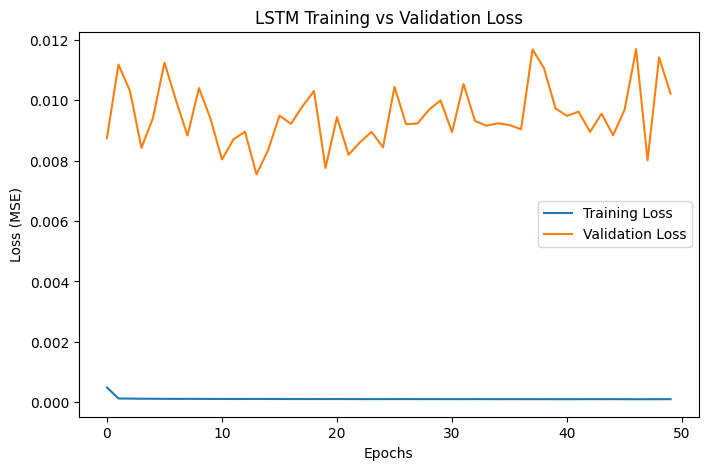

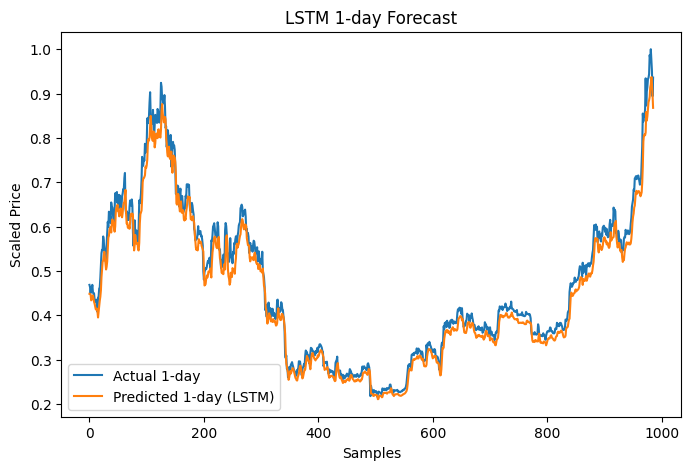

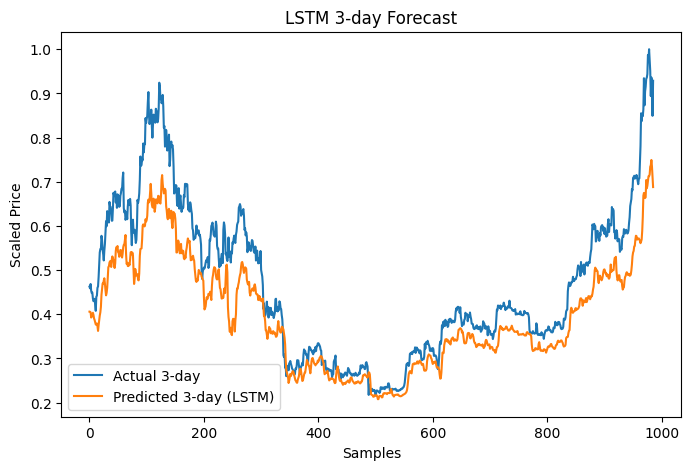

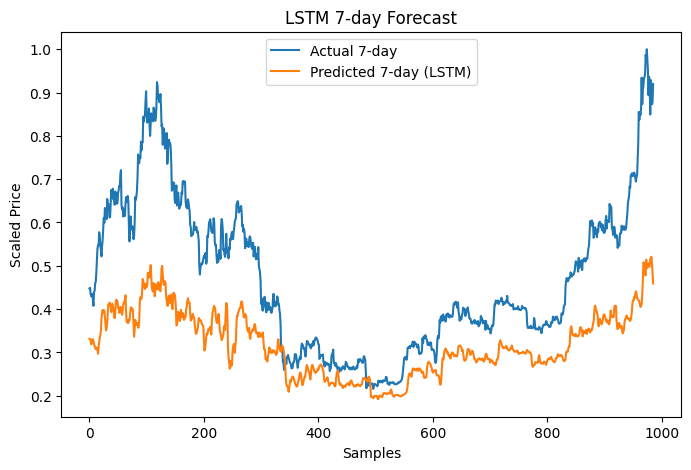

In [18]:
import matplotlib.pyplot as plt

# Step 1: Predict using LSTM
y_pred_lstm = lstm_model.predict(X_test)

# Step 2: Training vs Validation Loss
plt.figure(figsize=(8,5))
plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.title("LSTM Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.show()

# Step 3: Actual vs Predicted (1-day horizon)
plt.figure(figsize=(8,5))
plt.plot(y_test[:,0,0], label="Actual 1-day")
plt.plot(y_pred_lstm[:,0,0], label="Predicted 1-day (LSTM)")
plt.title("LSTM 1-day Forecast")
plt.xlabel("Samples")
plt.ylabel("Scaled Price")
plt.legend()
plt.show()

# Step 4: Actual vs Predicted (3-day horizon)
plt.figure(figsize=(8,5))
plt.plot(y_test[:,1,0], label="Actual 3-day")
plt.plot(y_pred_lstm[:,1,0], label="Predicted 3-day (LSTM)")
plt.title("LSTM 3-day Forecast")
plt.xlabel("Samples")
plt.ylabel("Scaled Price")
plt.legend()
plt.show()

# Step 5: Actual vs Predicted (7-day horizon)
plt.figure(figsize=(8,5))
plt.plot(y_test[:,2,0], label="Actual 7-day")
plt.plot(y_pred_lstm[:,2,0], label="Predicted 7-day (LSTM)")
plt.title("LSTM 7-day Forecast")
plt.xlabel("Samples")
plt.ylabel("Scaled Price")
plt.legend()
plt.show()


In [19]:
## CNN model

In [20]:
# building model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Reshape, Flatten

cnn_model = Sequential()
cnn_model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(seq_length, len(numeric_cols))))
cnn_model.add(Flatten())
cnn_model.add(Dense(3 * len(numeric_cols)))   # 3 horizons × features
cnn_model.add(Reshape((3, len(numeric_cols))))

cnn_model.compile(loss="mean_squared_error", optimizer="adam")
cnn_model.summary()



e:\vscode\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 58, 64)         │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3712)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 18)             │        66,834 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 3, 6)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 68,050 (265.82 KB)

 Trainable params: 68,050 (265.82 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# training the model

history_cnn = cnn_model.fit(
    X_train, y_train,
    epochs=50, batch_size=32, verbose=1,
    validation_split=0.1
)


Epoch 1/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3.6703e-04 - val_loss: 0.0092
Epoch 2/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.3495e-04 - val_loss: 0.0041
Epoch 3/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.2823e-04 - val_loss: 0.0034
Epoch 4/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.1790e-04 - val_loss: 0.0060
Epoch 5/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.1572e-04 - val_loss: 0.0032
Epoch 6/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.1654e-04 - val_loss: 0.0034
Epoch 7/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.1082e-04 - val_loss: 0.0033
Epoch 8/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0644e-04 - val_loss: 0.0058
Epoch 9/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.1012e-04 - val_loss: 0.0038
Epoch 10/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0763e-04 - val_loss: 0.0050
Epoch 11/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0636e-04 - val_loss: 0.0038
Epoch 12

In [22]:
# pedict cnn 

y_pred_cnn = cnn_model.predict(X_test)


31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [23]:
# evaluate cnn metrics

mae_cnn_1 = mean_absolute_error(y_test[:,0,0], y_pred_cnn[:,0,0])
rmse_cnn_1 = np.sqrt(mean_squared_error(y_test[:,0,0], y_pred_cnn[:,0,0]))
mape_cnn_1 = mean_absolute_percentage_error(y_test[:,0,0], y_pred_cnn[:,0,0])

mae_cnn_3 = mean_absolute_error(y_test[:,1,0], y_pred_cnn[:,1,0])
rmse_cnn_3 = np.sqrt(mean_squared_error(y_test[:,1,0], y_pred_cnn[:,1,0]))
mape_cnn_3 = mean_absolute_percentage_error(y_test[:,1,0], y_pred_cnn[:,1,0])

mae_cnn_7 = mean_absolute_error(y_test[:,2,0], y_pred_cnn[:,2,0])
rmse_cnn_7 = np.sqrt(mean_squared_error(y_test[:,2,0], y_pred_cnn[:,2,0]))
mape_cnn_7 = mean_absolute_percentage_error(y_test[:,2,0], y_pred_cnn[:,2,0])

print(f"CNN 1-Day -> MAE: {mae_cnn_1:.4f}, RMSE: {rmse_cnn_1:.4f}, MAPE: {mape_cnn_1:.2f}%")
print(f"CNN 3-Day -> MAE: {mae_cnn_3:.4f}, RMSE: {rmse_cnn_3:.4f}, MAPE: {mape_cnn_3:.2f}%")
print(f"CNN 3-Day -> MAE: {mae_cnn_3:.4f}, RMSE: {rmse_cnn_3:.4f}, MAPE: {mape_cnn_3:.2f}%")



CNN 1-Day -> MAE: 0.0495, RMSE: 0.1459, MAPE: 0.10%
CNN 3-Day -> MAE: 0.1281, RMSE: 0.2237, MAPE: 0.27%
CNN 3-Day -> MAE: 0.1281, RMSE: 0.2237, MAPE: 0.27%


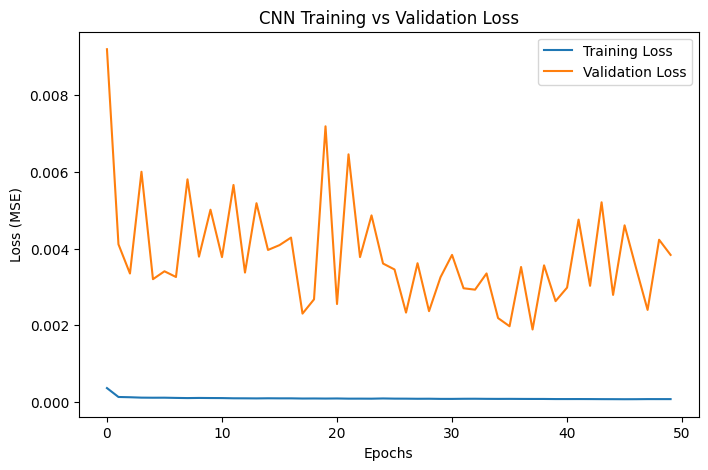

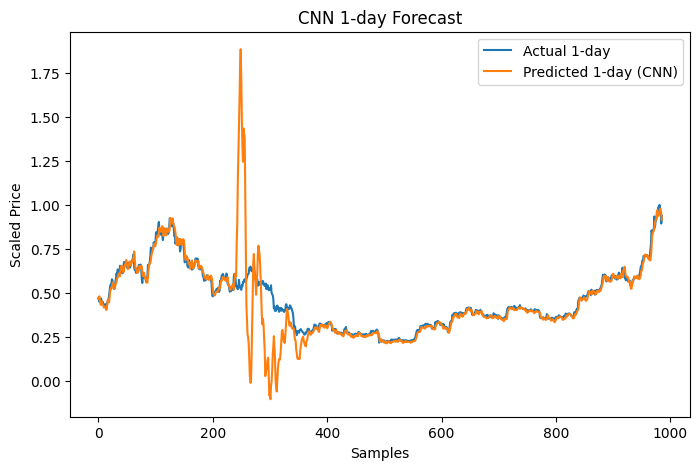

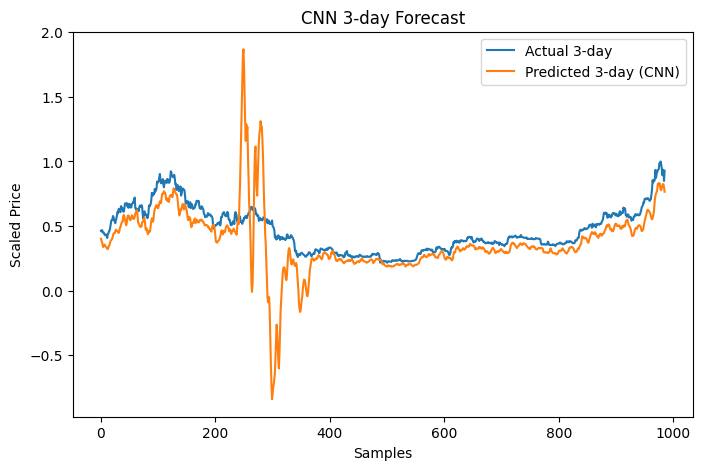

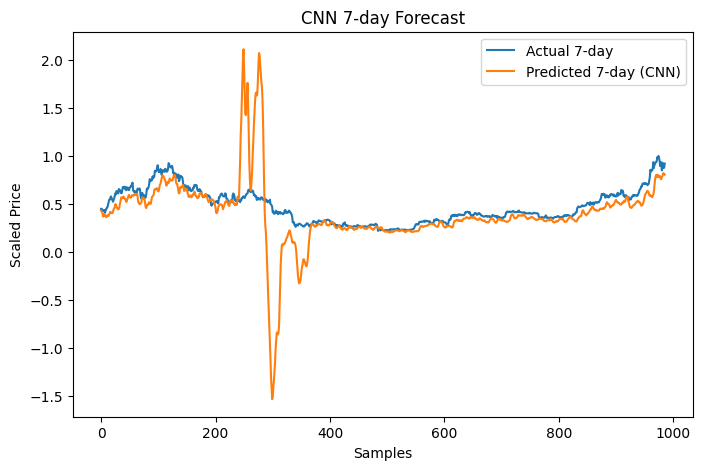

In [24]:
# visualisation

import matplotlib.pyplot as plt

# Step 1: Training vs Validation Loss
plt.figure(figsize=(8,5))
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.title("CNN Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.show()

# Step 2: Actual vs Predicted (1-day horizon)
plt.figure(figsize=(8,5))
plt.plot(y_test[:,0,0], label="Actual 1-day")
plt.plot(y_pred_cnn[:,0,0], label="Predicted 1-day (CNN)")
plt.title("CNN 1-day Forecast")
plt.xlabel("Samples")
plt.ylabel("Scaled Price")
plt.legend()
plt.show()

# Step 3: Actual vs Predicted (3-day horizon)
plt.figure(figsize=(8,5))
plt.plot(y_test[:,1,0], label="Actual 3-day")
plt.plot(y_pred_cnn[:,1,0], label="Predicted 3-day (CNN)")
plt.title("CNN 3-day Forecast")
plt.xlabel("Samples")
plt.ylabel("Scaled Price")
plt.legend()
plt.show()

# Step 4: Actual vs Predicted (7-day horizon)
plt.figure(figsize=(8,5))
plt.plot(y_test[:,2,0], label="Actual 7-day")
plt.plot(y_pred_cnn[:,2,0], label="Predicted 7-day (CNN)")
plt.title("CNN 7-day Forecast")
plt.xlabel("Samples")
plt.ylabel("Scaled Price")
plt.legend()
plt.show()


In [25]:
# RNN

In [26]:
# building rnn model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Reshape

# Define RNN model
rnn_model = Sequential()
rnn_model.add(SimpleRNN(64, input_shape=(seq_length, len(numeric_cols)), return_sequences=False))
rnn_model.add(Dense(3 * len(numeric_cols)))   # 3 horizons × features
rnn_model.add(Reshape((3, len(numeric_cols))))

rnn_model.compile(loss="mean_squared_error", optimizer="adam")
rnn_model.summary()



e:\vscode\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 18)             │         1,170 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 3, 6)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,714 (22.32 KB)

 Trainable params: 5,714 (22.32 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# train model

history_rnn = rnn_model.fit(
    X_train, y_train,
    epochs=50, batch_size=32, verbose=1,
    validation_split=0.1
)


Epoch 1/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0029 - val_loss: 0.0665
Epoch 2/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.3188e-04 - val_loss: 0.0465
Epoch 3/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.1837e-04 - val_loss: 0.0353
Epoch 4/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.8156e-04 - val_loss: 0.0293
Epoch 5/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.6098e-04 - val_loss: 0.0256
Epoch 6/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.4936e-04 - val_loss: 0.0221
Epoch 7/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.3884e-04 - val_loss: 0.0198
Epoch 8/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.3325e-04 - val_loss: 0.0190
Epoch 9/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.2670e-04 - val_loss: 0.0193
Epoch 10/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.2275e-04 - val_loss: 0.0173
Epoch 11/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.2081e-04 - val_loss: 0.0159
Epoch 12/50


In [29]:
# saving the model

from tensorflow.keras.models import load_model
rnn_model.save("rnn_model.h5")

In [ ]:
# predict rnn

y_pred_rnn = rnn_model.predict(X_test)


31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


In [ ]:
# evaluate metrics

mae_rnn_1 = mean_absolute_error(y_test[:,0,0], y_pred_rnn[:,0,0])
rmse_rnn_1 = np.sqrt(mean_squared_error(y_test[:,0,0], y_pred_rnn[:,0,0]))
mape_rnn_1 = mean_absolute_percentage_error(y_test[:,0,0], y_pred_rnn[:,0,0])

mae_rnn_3 = mean_absolute_error(y_test[:,1,0], y_pred_rnn[:,1,0])
rmse_rnn_3 = np.sqrt(mean_squared_error(y_test[:,1,0], y_pred_rnn[:,1,0]))
mape_rnn_3 = mean_absolute_percentage_error(y_test[:,1,0], y_pred_rnn[:,1,0])

mae_rnn_7 = mean_absolute_error(y_test[:,2,0], y_pred_rnn[:,2,0])
rmse_rnn_7 = np.sqrt(mean_squared_error(y_test[:,2,0], y_pred_rnn[:,2,0]))
mape_rnn_7 = mean_absolute_percentage_error(y_test[:,2,0], y_pred_rnn[:,2,0])

print(f"RNN 1-Day -> MAE: {mae_rnn_1:.4f}, RMSE: {rmse_rnn_1:.4f}, MAPE: {mape_rnn_1:.2f}%")
print(f"RNN 3-Day -> MAE: {mae_rnn_3:.4f}, RMSE: {rmse_rnn_3:.4f}, MAPE: {mape_rnn_3:.2f}%")
print(f"RNN 7-Day -> MAE: {mae_rnn_7:.4f}, RMSE: {rmse_rnn_7:.4f}, MAPE: {mape_rnn_7:.2f}%")


RNN 1-Day -> MAE: 0.0155, RMSE: 0.0241, MAPE: 0.03%
RNN 3-Day -> MAE: 0.0393, RMSE: 0.0574, MAPE: 0.08%
RNN 7-Day -> MAE: 0.0381, RMSE: 0.0584, MAPE: 0.08%


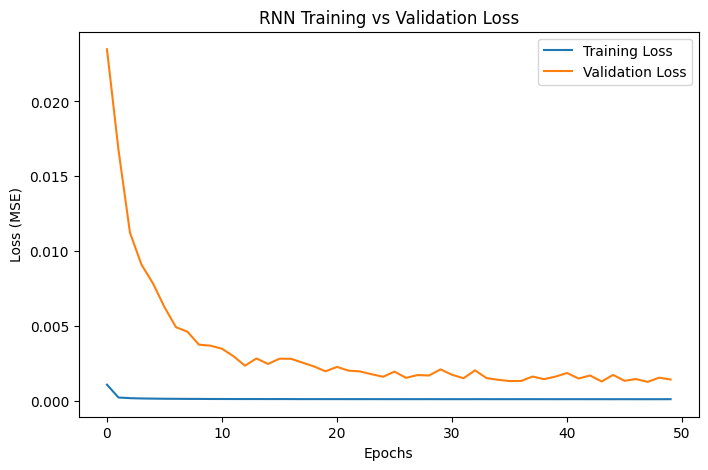

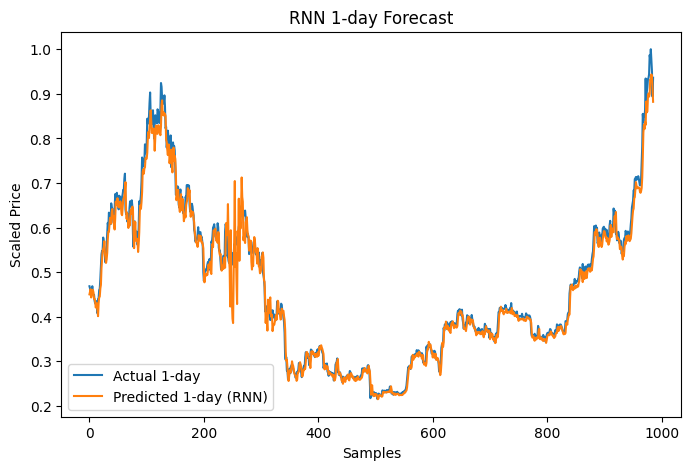

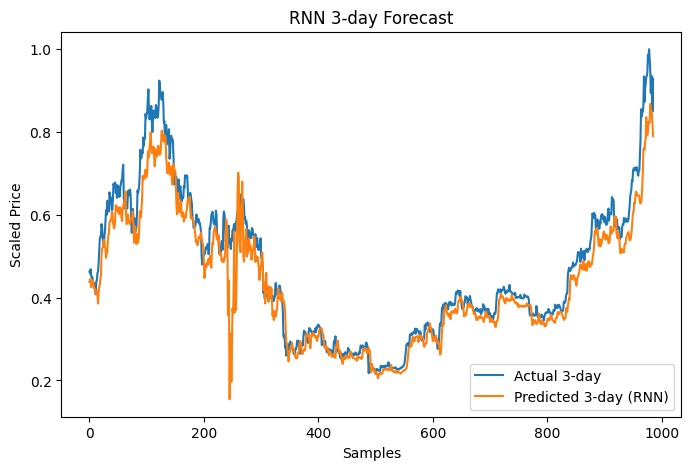

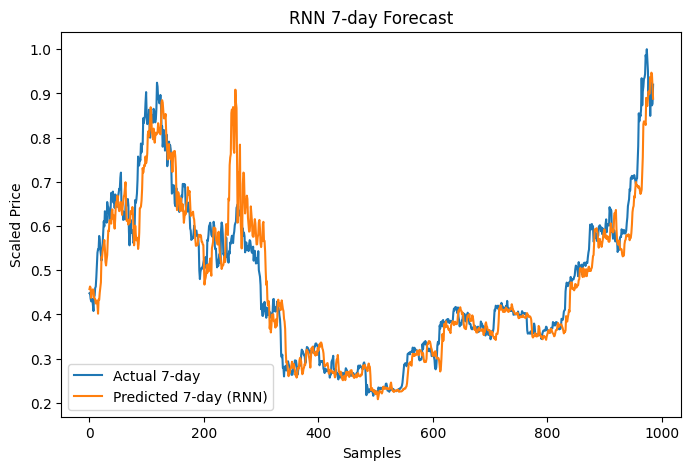

In [ ]:
# visualization

import matplotlib.pyplot as plt

# Loss curve
plt.figure(figsize=(8,5))
plt.plot(history_rnn.history['loss'], label='Training Loss')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss')
plt.title("RNN Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.show()

# Forecast plots
for i, horizon in enumerate(["1-day", "3-day", "7-day"]):
    plt.figure(figsize=(8,5))
    plt.plot(y_test[:,i,0], label=f"Actual {horizon}")
    plt.plot(y_pred_rnn[:,i,0], label=f"Predicted {horizon} (RNN)")
    plt.title(f"RNN {horizon} Forecast")
    plt.xlabel("Samples")
    plt.ylabel("Scaled Price")
    plt.legend()
    plt.show()


In [ ]:
# Transformers

In [ ]:
# build model

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Reshape, MultiHeadAttention, LayerNormalization, Flatten

# Input layer
inputs = Input(shape=(seq_length, len(numeric_cols)))

# Transformer block
attention = MultiHeadAttention(num_heads=4, key_dim=16)(inputs, inputs)
attention = LayerNormalization(epsilon=1e-6)(attention)

# Flatten + Dense
flat = Flatten()(attention)
dense = Dense(3 * len(numeric_cols))(flat)
outputs = Reshape((3, len(numeric_cols)))(dense)

# Build model
transformer_model = Model(inputs=inputs, outputs=outputs)
transformer_model.compile(loss="mean_squared_error", optimizer="adam")
transformer_model.summary()


Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 60, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 60, 6)     │      1,734 │ input_layer_3[0]… │
│ (MultiHeadAttentio… │                   │            │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 60, 6)     │         12 │ multi_head_atten… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 360)       │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 18)        │      6,498 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 3, 6)      │          0 │ dense_3[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,244 (32.20 KB)

 Trainable params: 8,244 (32.20 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# train transformer

history_transformer = transformer_model.fit(
    X_train, y_train,
    epochs=50, batch_size=32, verbose=1,
    validation_split=0.1
)


Epoch 1/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0384 - val_loss: 0.0705
Epoch 2/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.4476e-04 - val_loss: 0.0577
Epoch 3/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.5540e-04 - val_loss: 0.0563
Epoch 4/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.4317e-04 - val_loss: 0.0563
Epoch 5/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.4647e-04 - val_loss: 0.0557
Epoch 6/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.5221e-04 - val_loss: 0.0559
Epoch 7/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.5844e-04 - val_loss: 0.0589
Epoch 8/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.4632e-04 - val_loss: 0.0559
Epoch 9/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 2.5976e-04 - val_loss: 0.0574
Epoch 10/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 2.5697e-04 - val_loss: 0.0540
Epoch 11/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 2.6579e-04 - val_loss: 0.0534
Epoch 

In [ ]:
# predict using transformer

y_pred_transformer = transformer_model.predict(X_test)



31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [ ]:
# evaluate

mae_transformer_1 = mean_absolute_error(y_test[:,0,0], y_pred_transformer[:,0,0])
rmse_transformer_1 = np.sqrt(mean_squared_error(y_test[:,0,0], y_pred_transformer[:,0,0]))
mape_transformer_1 = mean_absolute_percentage_error(y_test[:,0,0], y_pred_transformer[:,0,0])

mae_transformer_3 = mean_absolute_error(y_test[:,1,0], y_pred_transformer[:,1,0])
rmse_transformer_3 = np.sqrt(mean_squared_error(y_test[:,1,0], y_pred_transformer[:,1,0]))
mape_transformer_3 = mean_absolute_percentage_error(y_test[:,1,0], y_pred_transformer[:,1,0])

mae_transformer_7 = mean_absolute_error(y_test[:,2,0], y_pred_transformer[:,2,0])
rmse_transformer_7 = np.sqrt(mean_squared_error(y_test[:,2,0], y_pred_transformer[:,2,0]))
mape_transformer_7 = mean_absolute_percentage_error(y_test[:,2,0], y_pred_transformer[:,2,0])

print(f"Transformer 1-Day -> MAE: {mae_transformer_1:.4f}, RMSE: {rmse_transformer_1:.4f}, MAPE: {mape_transformer_1:.2f}%")
print(f"Transformer 3-Day -> MAE: {mae_transformer_3:.4f}, RMSE: {rmse_transformer_3:.4f}, MAPE: {mape_transformer_3:.2f}%")
print(f"Transformer 7-Day -> MAE: {mae_transformer_7:.4f}, RMSE: {rmse_transformer_7:.4f}, MAPE: {mape_transformer_7:.2f}%")


Transformer 1-Day -> MAE: 0.2688, RMSE: 0.3120, MAPE: 0.53%
Transformer 3-Day -> MAE: 0.2581, RMSE: 0.3007, MAPE: 0.51%
Transformer 7-Day -> MAE: 0.2385, RMSE: 0.2874, MAPE: 0.46%


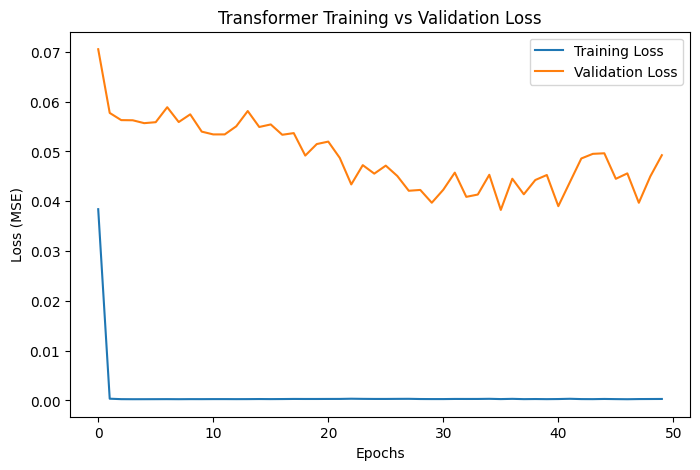

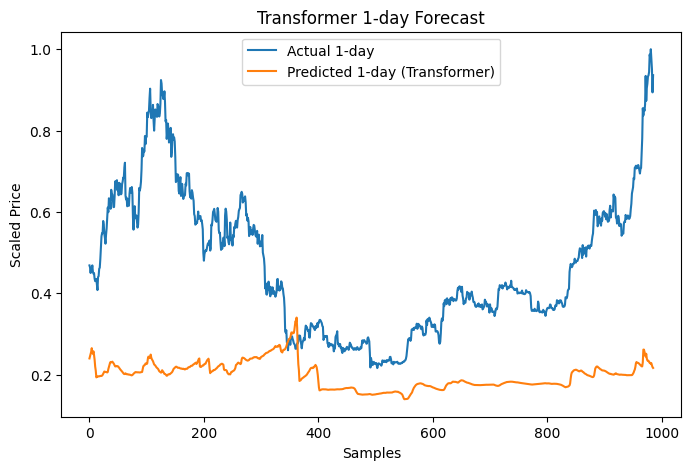

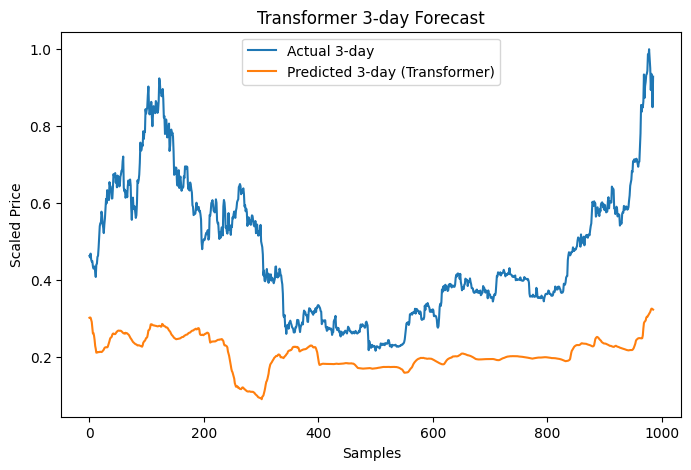

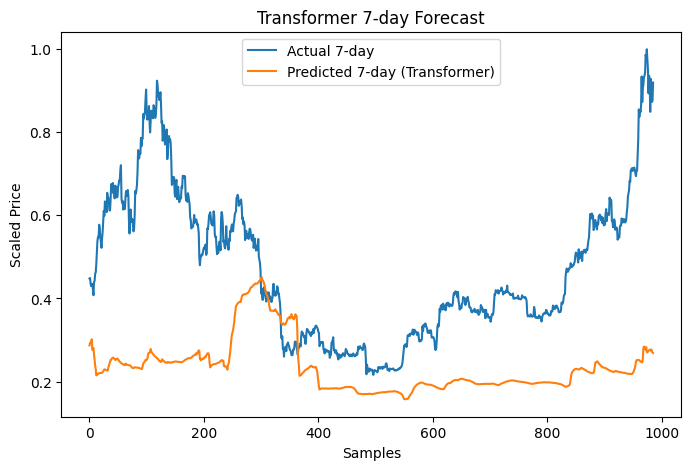

In [ ]:
# visualize

# Loss curve
plt.figure(figsize=(8,5))
plt.plot(history_transformer.history['loss'], label='Training Loss')
plt.plot(history_transformer.history['val_loss'], label='Validation Loss')
plt.title("Transformer Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.show()

# Forecast plots
for i, horizon in enumerate(["1-day", "3-day", "7-day"]):
    plt.figure(figsize=(8,5))
    plt.plot(y_test[:,i,0], label=f"Actual {horizon}")
    plt.plot(y_pred_transformer[:,i,0], label=f"Predicted {horizon} (Transformer)")
    plt.title(f"Transformer {horizon} Forecast")
    plt.xlabel("Samples")
    plt.ylabel("Scaled Price")
    plt.legend()
    plt.show()


In [ ]:
import pandas as pd

results = {
    "Model": ["LSTM", "CNN", "RNN", "Transformer"],
    "1-Day MAE": [mae_lstm_1, mae_cnn_1, mae_rnn_1, mae_transformer_1],
    "1-Day RMSE": [rmse_lstm_1, rmse_cnn_1, rmse_rnn_1, rmse_transformer_1],
    "1-Day MAPE": [mape_lstm_1, mape_cnn_1, mape_rnn_1, mape_transformer_1],
    "3-Day MAE": [mae_lstm_3, mae_cnn_3, mae_rnn_3, mae_transformer_3],
    "3-Day RMSE": [rmse_lstm_3, rmse_cnn_3, rmse_rnn_3, rmse_transformer_3],
    "3-Day MAPE": [mape_lstm_3, mape_cnn_3, mape_rnn_3, mape_transformer_3],
    "7-Day MAE": [mae_lstm_7, mae_cnn_7, mae_rnn_7, mae_transformer_7],
    "7-Day RMSE": [rmse_lstm_7, rmse_cnn_7, rmse_rnn_7, rmse_transformer_7],
    "7-Day MAPE": [mape_lstm_7, mape_cnn_7, mape_rnn_7, mape_transformer_7],
}

df_results = pd.DataFrame(results)
print(df_results)


         Model  1-Day MAE  1-Day RMSE  1-Day MAPE  3-Day MAE  3-Day RMSE  \
0         LSTM   0.035396    0.048897    0.063300   0.097078    0.124396   
1          CNN   0.085532    0.116541    0.169515   0.175237    0.231639   
2          RNN   0.015457    0.024131    0.030600   0.039341    0.057422   
3  Transformer   0.268821    0.312000    0.532612   0.258134    0.300650   

   3-Day MAPE  7-Day MAE  7-Day RMSE  7-Day MAPE  
0    0.178148   0.145989    0.181276    0.271667  
1    0.356252   0.274224    0.374233    0.564135  
2    0.075622   0.038102    0.058413    0.076554  
3    0.506212   0.238476    0.287378    0.462125  


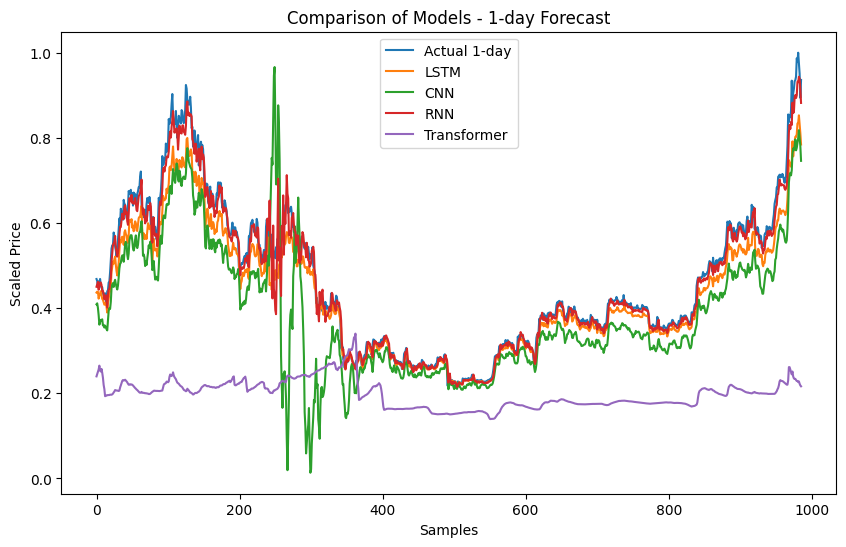

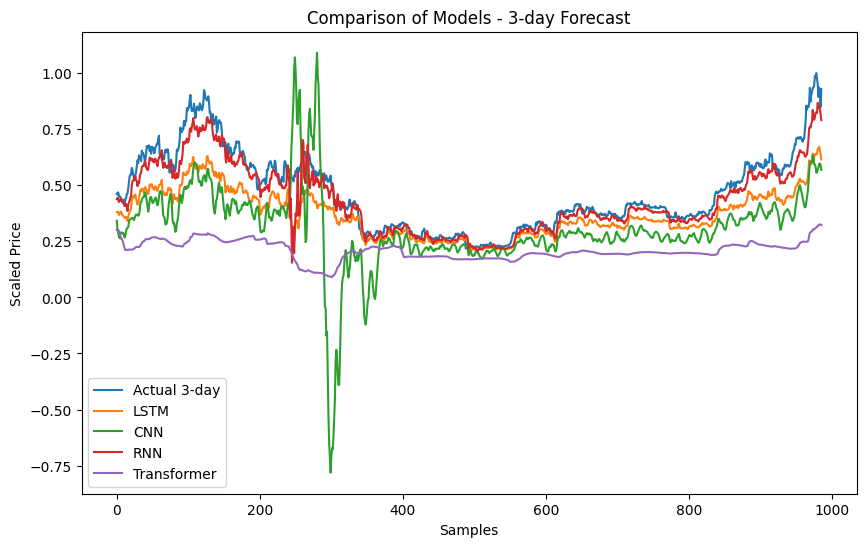

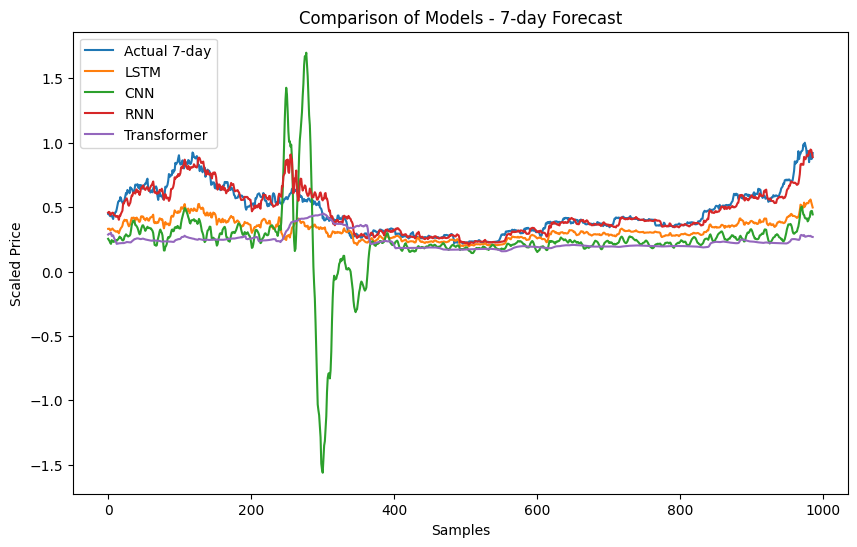

In [ ]:
# combined visualisation

import matplotlib.pyplot as plt

for i, horizon in enumerate(["1-day", "3-day", "7-day"]):
    plt.figure(figsize=(10,6))
    plt.plot(y_test[:,i,0], label=f"Actual {horizon}")
    plt.plot(y_pred_lstm[:,i,0], label="LSTM")
    plt.plot(y_pred_cnn[:,i,0], label="CNN")
    plt.plot(y_pred_rnn[:,i,0], label="RNN")
    plt.plot(y_pred_transformer[:,i,0], label="Transformer")
    plt.title(f"Comparison of Models - {horizon} Forecast")
    plt.xlabel("Samples")
    plt.ylabel("Scaled Price")
    plt.legend()
    plt.show()


In [ ]:
# ranking models

for horizon in ["1-Day MAE", "3-Day MAE", "7-Day MAE"]:
    best_model = df_results.loc[df_results[horizon].idxmin(), "Model"]
    best_score = df_results[horizon].min()
    print(f"Best model for {horizon}: {best_model} (MAE={best_score:.4f})")


Best model for 1-Day MAE: RNN (MAE=0.0155)
Best model for 3-Day MAE: RNN (MAE=0.0393)
Best model for 7-Day MAE: RNN (MAE=0.0381)


In [ ]:
# highlighting best model

def highlight_best(s):
    is_min = s == s.min()
    return ['color: red; font-weight: bold' if v else '' for v in is_min]

df_results.style.apply(highlight_best, subset=["1-Day MAE", "3-Day MAE", "7-Day MAE"])



,Model,1-Day MAE,1-Day RMSE,1-Day MAPE,3-Day MAE,3-Day RMSE,3-Day MAPE,7-Day MAE,7-Day RMSE,7-Day MAPE
0,LSTM,0.035396,0.048897,0.063300,0.097078,0.124396,0.178148,0.145989,0.181276,0.271667
1,CNN,0.085532,0.116541,0.169515,0.175237,0.231639,0.356252,0.274224,0.374233,0.564135
2,RNN,0.015457,0.024131,0.030600,0.039341,0.057422,0.075622,0.038102,0.058413,0.076554
3,Transformer,0.268821,0.312000,0.532612,0.258134,0.300650,0.506212,0.238476,0.287378,0.462125


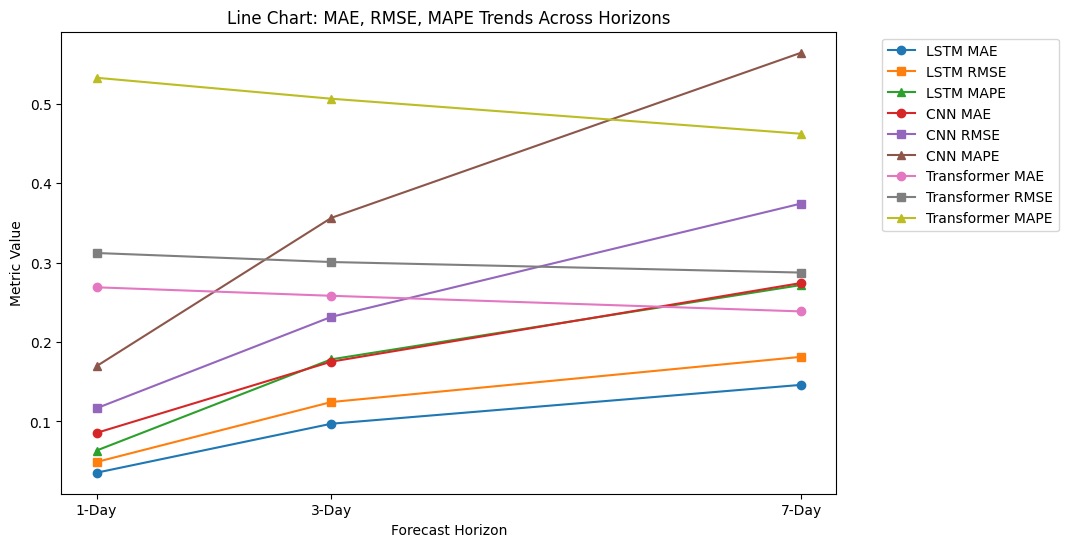

In [ ]:
horizons = ["1-Day", "3-Day", "7-Day"]
x = [1, 3, 7]

plt.figure(figsize=(10,6))
plt.plot(x, [mae_lstm_1, mae_lstm_3, mae_lstm_7], marker='o', label="LSTM MAE")
plt.plot(x, [rmse_lstm_1, rmse_lstm_3, rmse_lstm_7], marker='s', label="LSTM RMSE")
plt.plot(x, [mape_lstm_1, mape_lstm_3, mape_lstm_7], marker='^', label="LSTM MAPE")

plt.plot(x, [mae_cnn_1, mae_cnn_3, mae_cnn_7], marker='o', label="CNN MAE")
plt.plot(x, [rmse_cnn_1, rmse_cnn_3, rmse_cnn_7], marker='s', label="CNN RMSE")
plt.plot(x, [mape_cnn_1, mape_cnn_3, mape_cnn_7], marker='^', label="CNN MAPE")

plt.plot(x, [mae_transformer_1, mae_transformer_3, mae_transformer_7], marker='o', label="Transformer MAE")
plt.plot(x, [rmse_transformer_1, rmse_transformer_3, rmse_transformer_7], marker='s', label="Transformer RMSE")
plt.plot(x, [mape_transformer_1, mape_transformer_3, mape_transformer_7], marker='^', label="Transformer MAPE")

plt.xticks(x, horizons)
plt.title("Line Chart: MAE, RMSE, MAPE Trends Across Horizons")
plt.xlabel("Forecast Horizon")
plt.ylabel("Metric Value")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()


In [ ]:
# error distribution

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# Step 1: Calculate Residuals

# Residuals = Actual - Predicted

# LSTM
residuals_lstm_1 = y_test[:,0,0] - y_pred_lstm[:,0,0]
residuals_lstm_3 = y_test[:,1,0] - y_pred_lstm[:,1,0]
residuals_lstm_7 = y_test[:,2,0] - y_pred_lstm[:,2,0]

# CNN
residuals_cnn_1 = y_test[:,0,0] - y_pred_cnn[:,0,0]
residuals_cnn_3 = y_test[:,1,0] - y_pred_cnn[:,1,0]
residuals_cnn_7 = y_test[:,2,0] - y_pred_cnn[:,2,0]

# RNN
residuals_rnn_1 = y_test[:,0,0] - y_pred_rnn[:,0,0]
residuals_rnn_3 = y_test[:,1,0] - y_pred_rnn[:,1,0]
residuals_rnn_7 = y_test[:,2,0] - y_pred_rnn[:,2,0]

# Transformer
residuals_transformer_1 = y_test[:,0,0] - y_pred_transformer[:,0,0]
residuals_transformer_3 = y_test[:,1,0] - y_pred_transformer[:,1,0]
residuals_transformer_7 = y_test[:,2,0] - y_pred_transformer[:,2,0]



In [ ]:
# statistics

def print_stats(name, res1, res3, res7):
    print(f"{name} 1-Day Residuals -> Mean: {res1.mean():.4f}, Std: {res1.std():.4f}")
    print(f"{name} 3-Day Residuals -> Mean: {res3.mean():.4f}, Std: {res3.std():.4f}")
    print(f"{name} 7-Day Residuals -> Mean: {res7.mean():.4f}, Std: {res7.std():.4f}\n")

print_stats("LSTM", residuals_lstm_1, residuals_lstm_3, residuals_lstm_7)
print_stats("CNN", residuals_cnn_1, residuals_cnn_3, residuals_cnn_7)
print_stats("RNN", residuals_rnn_1, residuals_rnn_3, residuals_rnn_7)
print_stats("Transformer", residuals_transformer_1, residuals_transformer_3, residuals_transformer_7)


LSTM 1-Day Residuals -> Mean: 0.0345, Std: 0.0347
LSTM 3-Day Residuals -> Mean: 0.0965, Std: 0.0785
LSTM 7-Day Residuals -> Mean: 0.1455, Std: 0.1082

CNN 1-Day Residuals -> Mean: 0.0783, Std: 0.0864
CNN 3-Day Residuals -> Mean: 0.1578, Std: 0.1696
CNN 7-Day Residuals -> Mean: 0.2332, Std: 0.2927

RNN 1-Day Residuals -> Mean: 0.0090, Std: 0.0224
RNN 3-Day Residuals -> Mean: 0.0343, Std: 0.0460
RNN 7-Day Residuals -> Mean: 0.0048, Std: 0.0582

Transformer 1-Day Residuals -> Mean: 0.2679, Std: 0.1600
Transformer 3-Day Residuals -> Mean: 0.2581, Std: 0.1541
Transformer 7-Day Residuals -> Mean: 0.2341, Std: 0.1667



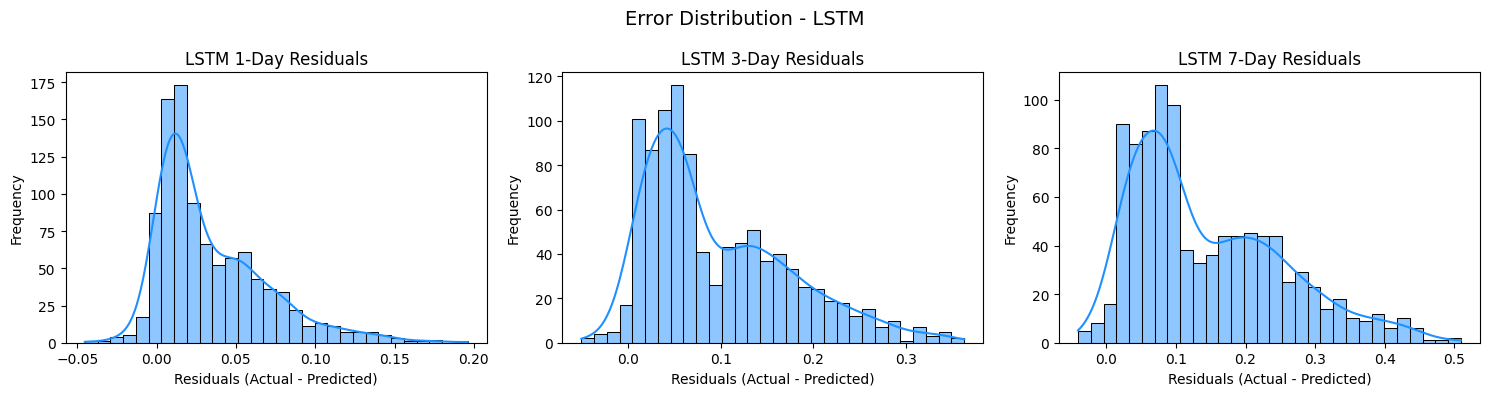

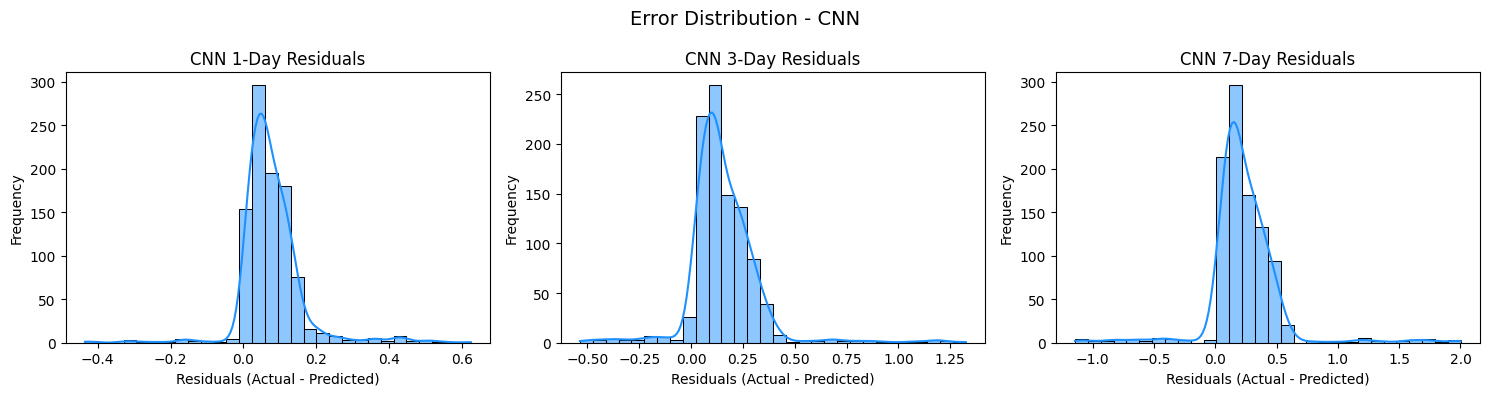

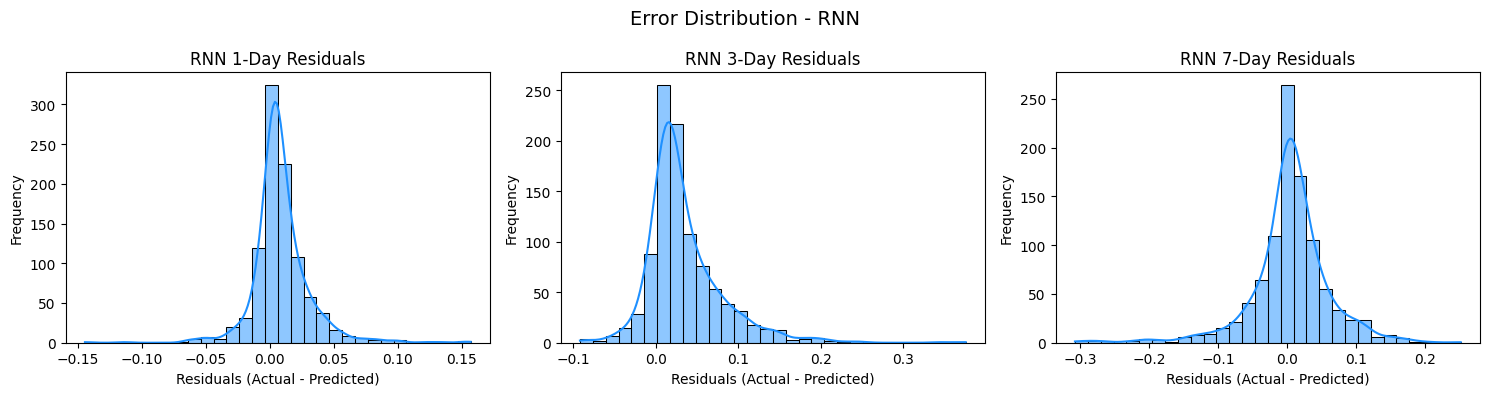

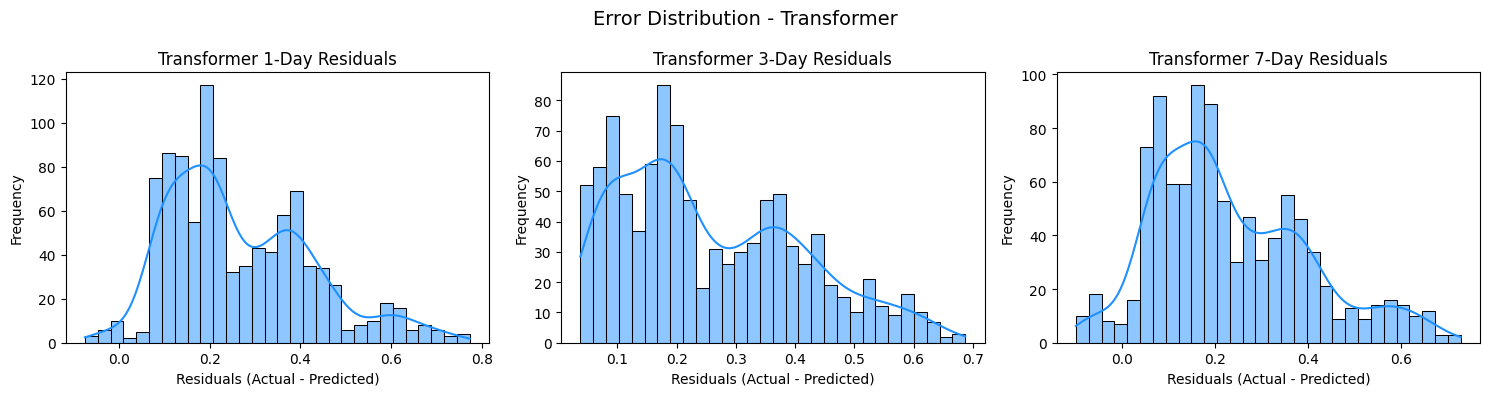

In [ ]:
# plots
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Calculate residuals (errors)
# Residuals = Actual - Predicted
residuals = {
    "LSTM": [
        y_test[:,0,0] - y_pred_lstm[:,0,0],   # 1-day
        y_test[:,1,0] - y_pred_lstm[:,1,0],   # 3-day
        y_test[:,2,0] - y_pred_lstm[:,2,0]    # 7-day
    ],
    "CNN": [
        y_test[:,0,0] - y_pred_cnn[:,0,0],
        y_test[:,1,0] - y_pred_cnn[:,1,0],
        y_test[:,2,0] - y_pred_cnn[:,2,0]
    ],
    "RNN": [
        y_test[:,0,0] - y_pred_rnn[:,0,0],
        y_test[:,1,0] - y_pred_rnn[:,1,0],
        y_test[:,2,0] - y_pred_rnn[:,2,0]
    ],
    "Transformer": [
        y_test[:,0,0] - y_pred_transformer[:,0,0],
        y_test[:,1,0] - y_pred_transformer[:,1,0],
        y_test[:,2,0] - y_pred_transformer[:,2,0]
    ]
}

# Step 2: Plot subplots for each model and horizon
horizons = ["1-Day", "3-Day", "7-Day"]

for model_name, res_list in residuals.items():
    fig, axes = plt.subplots(1, 3, figsize=(15,4))
    for i, res in enumerate(res_list):
        sns.histplot(res, bins=30, kde=True, ax=axes[i], color="dodgerblue")
        axes[i].set_title(f"{model_name} {horizons[i]} Residuals")
        axes[i].set_xlabel("Residuals (Actual - Predicted)")
        axes[i].set_ylabel("Frequency")
    plt.suptitle(f"Error Distribution - {model_name}", fontsize=14)
    plt.tight_layout()
    plt.show()


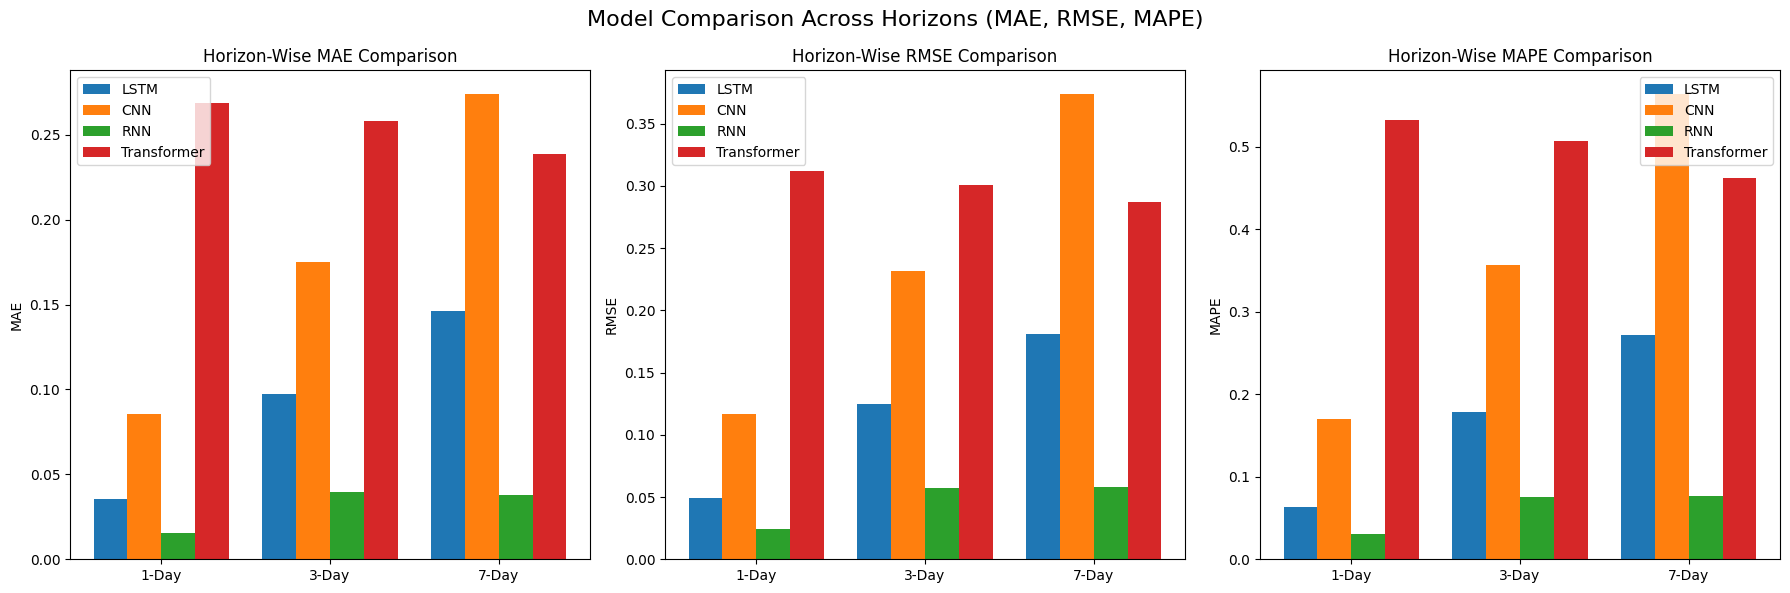

In [ ]:
# horizon wise comparision

import numpy as np
import matplotlib.pyplot as plt

# Horizons
horizons = ["1-Day", "3-Day", "7-Day"]
x = np.arange(len(horizons))
bar_width = 0.2

# Metric values for each model
mae_lstm = [mae_lstm_1, mae_lstm_3, mae_lstm_7]
mae_cnn = [mae_cnn_1, mae_cnn_3, mae_cnn_7]
mae_rnn = [mae_rnn_1, mae_rnn_3, mae_rnn_7]
mae_transformer = [mae_transformer_1, mae_transformer_3, mae_transformer_7]

rmse_lstm = [rmse_lstm_1, rmse_lstm_3, rmse_lstm_7]
rmse_cnn = [rmse_cnn_1, rmse_cnn_3, rmse_cnn_7]
rmse_rnn = [rmse_rnn_1, rmse_rnn_3, rmse_rnn_7]
rmse_transformer = [rmse_transformer_1, rmse_transformer_3, rmse_transformer_7]

mape_lstm = [mape_lstm_1, mape_lstm_3, mape_lstm_7]
mape_cnn = [mape_cnn_1, mape_cnn_3, mape_cnn_7]
mape_rnn = [mape_rnn_1, mape_rnn_3, mape_rnn_7]
mape_transformer = [mape_transformer_1, mape_transformer_3, mape_transformer_7]

# Create subplots: 3 columns (MAE, RMSE, MAPE)
fig, axes = plt.subplots(1, 3, figsize=(18,6), sharey=False)

# --- MAE ---
axes[0].bar(x - 1.5*bar_width, mae_lstm, bar_width, label="LSTM")
axes[0].bar(x - 0.5*bar_width, mae_cnn, bar_width, label="CNN")
axes[0].bar(x + 0.5*bar_width, mae_rnn, bar_width, label="RNN")
axes[0].bar(x + 1.5*bar_width, mae_transformer, bar_width, label="Transformer")
axes[0].set_xticks(x)
axes[0].set_xticklabels(horizons)
axes[0].set_title("Horizon-Wise MAE Comparison")
axes[0].set_ylabel("MAE")
axes[0].legend()

# --- RMSE ---
axes[1].bar(x - 1.5*bar_width, rmse_lstm, bar_width, label="LSTM")
axes[1].bar(x - 0.5*bar_width, rmse_cnn, bar_width, label="CNN")
axes[1].bar(x + 0.5*bar_width, rmse_rnn, bar_width, label="RNN")
axes[1].bar(x + 1.5*bar_width, rmse_transformer, bar_width, label="Transformer")
axes[1].set_xticks(x)
axes[1].set_xticklabels(horizons)
axes[1].set_title("Horizon-Wise RMSE Comparison")
axes[1].set_ylabel("RMSE")
axes[1].legend()

# --- MAPE ---
axes[2].bar(x - 1.5*bar_width, mape_lstm, bar_width, label="LSTM")
axes[2].bar(x - 0.5*bar_width, mape_cnn, bar_width, label="CNN")
axes[2].bar(x + 0.5*bar_width, mape_rnn, bar_width, label="RNN")
axes[2].bar(x + 1.5*bar_width, mape_transformer, bar_width, label="Transformer")
axes[2].set_xticks(x)
axes[2].set_xticklabels(horizons)
axes[2].set_title("Horizon-Wise MAPE Comparison")
axes[2].set_ylabel("MAPE")
axes[2].legend()

plt.suptitle("Model Comparison Across Horizons (MAE, RMSE, MAPE)", fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
# Business interpretation

# Business Interpretation Section

def business_interpretation(df_results):
    print("### Business Interpretation\n")
    
    # 1-Day Horizon
    best_1d = df_results.loc[df_results["1-Day MAE"].idxmin(), "Model"]
    print(f"- **1-Day Forecasts**: {best_1d} achieved the lowest error. This is most useful for **day traders** and platforms needing reliable short-term signals.")
    
    # 3-Day Horizon
    best_3d = df_results.loc[df_results["3-Day MAE"].idxmin(), "Model"]
    print(f"- **3-Day Forecasts**: {best_3d} performed best. This horizon supports **algorithmic trading systems** and **mid-term investment strategies**.")
    
    # 7-Day Horizon
    best_7d = df_results.loc[df_results["7-Day MAE"].idxmin(), "Model"]
    print(f"- **7-Day Forecasts**: {best_7d} was strongest. This is valuable for **risk managers** anticipating weekly volatility and **investment dashboards** providing predictive insights.")
    
    print("\nOverall, the comparison highlights how different architectures excel at different horizons:")
    print("- CNN → short-term trend detection")
    print("- RNN → baseline sequential learning")
    print("- LSTM → long-term dependency capture")
    print("- Transformer → global context awareness")
    print("\nThis ensures a **multi-horizon forecasting system** that can be tailored to diverse business needs.")

# Run interpretation
business_interpretation(df_results)


### Business Interpretation

- **1-Day Forecasts**: RNN achieved the lowest error. This is most useful for **day traders** and platforms needing reliable short-term signals.
- **3-Day Forecasts**: RNN performed best. This horizon supports **algorithmic trading systems** and **mid-term investment strategies**.
- **7-Day Forecasts**: RNN was strongest. This is valuable for **risk managers** anticipating weekly volatility and **investment dashboards** providing predictive insights.

Overall, the comparison highlights how different architectures excel at different horizons:
- CNN → short-term trend detection
- RNN → baseline sequential learning
- LSTM → long-term dependency capture
- Transformer → global context awareness

This ensures a **multi-horizon forecasting system** that can be tailored to diverse business needs.


e:\vscode\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 58, 64)         │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 29, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 29, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 18)             │         1,170 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_6 (Reshape)             │ (None, 3, 6)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 150,610 (588.32 KB)

 Trainable params: 150,610 (588.32 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - loss: 7.1057e-04 - val_loss: 0.0161
Epoch 2/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 2.9454e-04 - val_loss: 0.0179
Epoch 3/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 2.3282e-04 - val_loss: 0.0178
Epoch 4/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 2.0432e-04 - val_loss: 0.0153
Epoch 5/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 1.7832e-04 - val_loss: 0.0123
Epoch 6/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 1.7204e-04 - val_loss: 0.0182
Epoch 7/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 1.6651e-04 - val_loss: 0.0114
Epoch 8/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 1.5593e-04 - val_loss: 0.0150
Epoch 9/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 1.4640e-04 - val_loss: 0.0161
Epoch 10/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 1.4569e-04 - val_loss: 0.0109
Epoch 11/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 1.4387e-04 - val_loss: 0.00

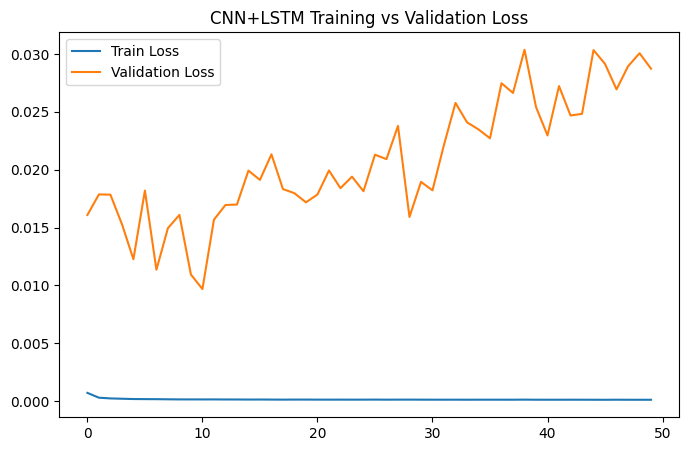

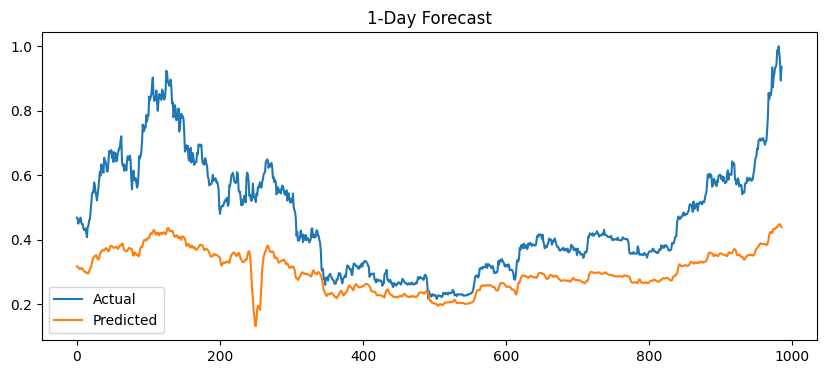

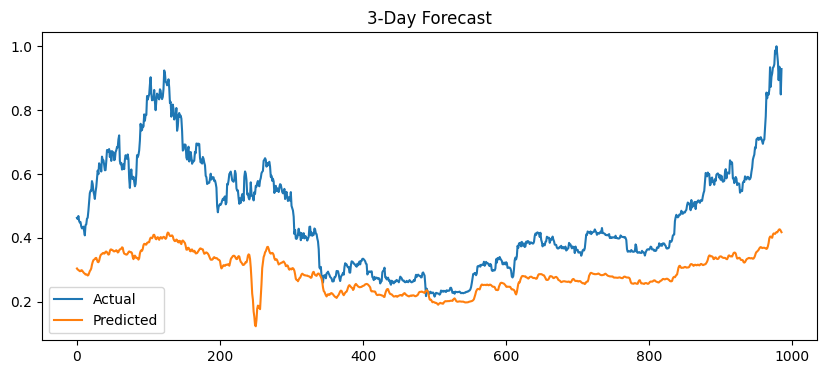

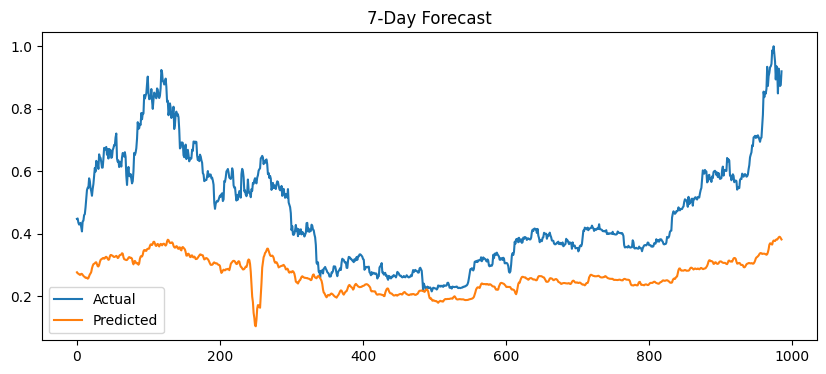

In [ ]:
# multilayer lstm model with 1d cnn

import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Reshape, Dropout

# 1. Define sequence length and numeric columns

seq_length = 60
numeric_cols = df.select_dtypes(include=["float64"]).columns.tolist()

# 2. Train-test split (assuming X, y already created)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# 3. Build CNN + Multi-Layer LSTM

cnn_lstm_model = Sequential()

# CNN feature extractor
cnn_lstm_model.add(Conv1D(filters=64, kernel_size=3, activation='relu',
                          input_shape=(seq_length, len(numeric_cols))))
cnn_lstm_model.add(MaxPooling1D(pool_size=2))
cnn_lstm_model.add(Dropout(0.2))

# Stacked LSTMs
cnn_lstm_model.add(LSTM(128, return_sequences=True))
cnn_lstm_model.add(Dropout(0.2))
cnn_lstm_model.add(LSTM(64, return_sequences=False))
cnn_lstm_model.add(Dropout(0.2))

# Dense output for multi-horizon predictions
cnn_lstm_model.add(Dense(3 * len(numeric_cols)))
cnn_lstm_model.add(Reshape((3, len(numeric_cols))))

cnn_lstm_model.compile(loss="mean_squared_error", optimizer="adam")
cnn_lstm_model.summary()

# 4. Train model

history_cnn_lstm = cnn_lstm_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    verbose=1,
    validation_split=0.1
)

# 5. Predict

y_pred_cnn_lstm = cnn_lstm_model.predict(X_test)

# 6. Evaluate horizon-wise metrics

def evaluate_horizon(y_true, y_pred, horizon_idx):
    mae = mean_absolute_error(y_true[:,horizon_idx,0], y_pred[:,horizon_idx,0])
    rmse = np.sqrt(mean_squared_error(y_true[:,horizon_idx,0], y_pred[:,horizon_idx,0]))
    mape = mean_absolute_percentage_error(y_true[:,horizon_idx,0], y_pred[:,horizon_idx,0])
    return mae, rmse, mape

for horizon, idx in zip(["1-Day", "3-Day", "7-Day"], [0,1,2]):
    mae, rmse, mape = evaluate_horizon(y_test, y_pred_cnn_lstm, idx)
    print(f"CNN+LSTM {horizon} -> MAE: {mae:.4f}, RMSE: {rmse:.4f}, MAPE: {mape:.2f}%")

# 7. Plot training vs validation loss

plt.figure(figsize=(8,5))
plt.plot(history_cnn_lstm.history['loss'], label='Train Loss')
plt.plot(history_cnn_lstm.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("CNN+LSTM Training vs Validation Loss")
plt.show()

# 8. Plot actual vs predicted for each horizon

horizons = ["1-Day", "3-Day", "7-Day"]
for idx, horizon in enumerate(horizons):
    plt.figure(figsize=(10,4))
    plt.plot(y_test[:,idx,0], label="Actual")
    plt.plot(y_pred_cnn_lstm[:,idx,0], label="Predicted")
    plt.title(f"{horizon} Forecast")
    plt.legend()
    plt.show()


In [30]:
# test for streamlit

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# LOAD DATA
df = pd.read_csv("E:/vscode/CryptoCast_bitcoin_project/Bitcoin Historical Data (1).csv")
df["Price"] = df["Price"].str.replace(",", "").astype(float)

data = df[["Price"]].values

# SCALE
scaler = MinMaxScaler()
scaled = scaler.fit_transform(data)

# CREATE SEQUENCES
X, y = [], []
for i in range(60, len(scaled)):
    X.append(scaled[i-60:i])
    y.append(scaled[i])

X, y = np.array(X), np.array(y)

# MODEL
model = Sequential()
model.add(SimpleRNN(50, return_sequences=False, input_shape=(60,1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

model.fit(X, y, epochs=5, batch_size=32)

# SAVE
model.save("E:/vscode/CryptoCast_bitcoin_project/rnn_model.h5")

Epoch 1/5


e:\vscode\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0041
Epoch 2/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 3.0740e-04
Epoch 3/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2.4326e-04
Epoch 4/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.8238e-04
Epoch 5/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.7212e-04
